In [1]:
# ecg filter
import numpy as np
from scipy.signal import resample, butter, filtfilt, find_peaks, iirnotch
from scipy.interpolate import CubicSpline

def downsample(x, fs, fs_target, time):
    num_samples = int(len(x) * fs_target / fs)
    x_resample = resample(x, num_samples)
    time_resample = np.linspace(time.iloc[0], time.iloc[-1], num_samples)
    return x_resample, time_resample

def baseline_correction(time, x, fs=125):
    min_distance = int(0.5 * fs) 
    peaks, _ = find_peaks(-x, distance=min_distance, prominence=0.1)

    if len(peaks) < 2:
        raise ValueError('lembah terlalu sedikit untuk interpolasi')
    
    t_val = time[peaks]
    s_val = x[peaks]

    cs = CubicSpline(t_val, s_val, bc_type='natural')
    baseline_dc = cs(time)
    x_corrected = x - baseline_dc

    return x_corrected, baseline_dc

def bpf(x, low_cut, high_cut, fs = 125, order=4):
    nyq = 0.5 * fs
    low = low_cut / nyq
    high = high_cut / nyq

    b, a = butter(order, [low, high], btype='bandpass', analog=False)
    x_clean = filtfilt(b, a, x)
    return x_clean

def ac_p2p(ac_signal, fs=125):
    min_distance = int(0.5 * fs)
    
    peaks, _ = find_peaks(ac_signal, distance=min_distance, prominence=10)
    troughs, _ = find_peaks(-ac_signal, distance=min_distance, prominence=10)
    
    num_beats = min(len(peaks), len(troughs))
    if num_beats == 0:
        return 0
        
    p2p_values = []
    for i in range(num_beats):
        amp = ac_signal[peaks[i]] - ac_signal[troughs[i]]
        p2p_values.append(amp)
        
    return np.mean(p2p_values)

def Spo2(ac_ir, dc_ir, ac_red, dc_red):
    mean_dc_ir = np.mean(np.abs(dc_ir))
    mean_dc_red = np.mean(np.abs(dc_red))
    
    PI_red = ac_red / mean_dc_red
    PI_ir = ac_ir / mean_dc_ir

    R = PI_red / PI_ir
    spo2 = -17.8327 * (R**2) + (15.6006) * R + 94.6457
    spo2 = np.clip(spo2, 0, 100)
    return spo2, PI_red, PI_ir

def notch(ecg, freq=50.0, fs=125, Q=30.0):
    nyq = 0.5 * fs
    if freq >= nyq:
        return ecg
    b, a = iirnotch(freq, Q, fs)
    return filtfilt(b, a, ecg)

def hr(ecg, fs=125):
    n_samples = len(ecg)
    mean_ecg = np.mean(ecg)
    std_ecg = np.std(ecg)
    min_height = mean_ecg + (0.5 * std_ecg)
    min_distance_samples = int(0.3 * fs)
    
    candidate_peaks = []
    for i in range(1, n_samples - 1):
        if ecg[i] > min_height:
            if ecg[i] > ecg[i - 1] and ecg[i] > ecg[i + 1]:
                candidate_peaks.append(i)
                
    r_peaks = []
    if len(candidate_peaks) > 0:
        r_peaks.append(candidate_peaks[0])
        for p in candidate_peaks[1:]:
            if p - r_peaks[-1] >= min_distance_samples:
                r_peaks.append(p)
            else:
                if ecg[p] > ecg[r_peaks[-1]]:
                    r_peaks[-1] = p
                    
    r_peaks = np.array(r_peaks)
    if len(r_peaks) > 1:
        rr_intervals_samples = np.diff(r_peaks)
        rr_intervals_seconds = rr_intervals_samples / fs
        mean_rr_interval = np.mean(rr_intervals_seconds)
        bpm = 60.0 / mean_rr_interval
    else:
        bpm = 0.0
        
    return bpm, r_peaks

def rr(ecg, fs=125):
    n_samples = len(ecg)
    total_seconds = n_samples / fs
    
    # 1. Ambil qrs_signal, r_peaks, dan ecg_clean dari fungsi isolate_qrs sebelumnya
    _, r_peaks = hr(ecg, fs=fs)
    r_peaks = np.array(r_peaks)
    
    # Validasi jika detak jantung terlalu sedikit untuk interpolasi spline
    if len(r_peaks) < 4:
        return 0.0, np.zeros(n_samples), np.array([])
        
    # 2. Pembuatan baseline lokal untuk koreksi sinyal (Moving Average 1 detik)
    blen_samples = int(1.0 * fs)
    baseline_local = np.convolve(ecg, np.ones(2*blen_samples+1)/(2*blen_samples+1), mode='same')
    ecg_corrected = ecg - baseline_local
    
    # 3. Hitung Integrasi Area QRS (Jendela ±40 ms dari R-peak)
    win_samples = int(0.04 * fs) 
    edr_samples = []
    
    for idx in r_peaks:
        t0 = max(0, idx - win_samples)
        t1 = min(n_samples, idx + win_samples)
        qrs_area = np.sum(ecg_corrected[t0:t1]) # Penjumlahan area amplitudo QRS
        edr_samples.append(qrs_area)
        
    edr_samples = np.array(edr_samples)
    
    # 4. Adaptive Tracking (Normalisasi deviasi relatif 'r')
    xm = 0.0  # Rata-rata area running
    xd = 1.0  # Deviasi absolut running
    xc = 0    # Counter detak
    
    r_signals = []
    for x in edr_samples:
        d = x - xm
        if xc < 500:
            xc += 1
            dn = d / xc
        else:
            dn = d / xc
            xdmax = 3.0 * xd / xc
            dn = np.clip(dn, -xdmax, xdmax) # Kliping nilai ekstrem
            
        xm += dn
        xd += abs(dn) - xd / xc
        if xd < 1e-3: xd = 1e-3
        
        r = d / xd
        r_signals.append(r)
        
    r_signals = np.array(r_signals)
    
    # 5. Interpolasi Spline untuk membentuk sinyal pernapasan kontinu
    cs = CubicSpline(r_peaks, r_signals, extrapolate=False)
    
    # Isi area sinyal kontinu dari puncak R pertama hingga terakhir
    resp_signal = cs(np.arange(r_peaks[0], r_peaks[-1]))
    
    resp_signal_full = np.zeros(n_samples)
    resp_signal_full[r_peaks[0]:r_peaks[-1]] = resp_signal
    resp_signal_full[:r_peaks[0]] = resp_signal[0]
    resp_signal_full[r_peaks[-1]:] = resp_signal[-1]
    
    # 6. Deteksi Puncak Pernapasan pada Sinyal EDR (Jarak min 1.6 detik ~ 37.5 BrPM)
    min_distance_resp = int(1.6 * fs)
    mean_resp = np.mean(resp_signal_full)
    
    # Fase mencari kandidat puncak lokal pernapasan
    candidate_resp_peaks = []
    for i in range(1, n_samples - 1):
        if resp_signal_full[i] > mean_resp:
            if resp_signal_full[i] > resp_signal_full[i - 1] and resp_signal_full[i] > resp_signal_full[i + 1]:
                candidate_resp_peaks.append(i)
                
    # Seleksi puncak berdasarkan jarak minimum (Refractory Period pernapasan)
    resp_peaks = []
    if len(candidate_resp_peaks) > 0:
        resp_peaks.append(candidate_resp_peaks[0])
        for p in candidate_resp_peaks[1:]:
            if p - resp_peaks[-1] >= min_distance_resp:
                resp_peaks.append(p)
            else:
                if resp_signal_full[p] > resp_signal_full[resp_peaks[-1]]:
                    resp_peaks[-1] = p # Ambil amplitudo yang lebih tinggi
                    
    resp_peaks = np.array(resp_peaks)
    
    # 7. Hitung Respiration Rate (Laju Pernapasan per Menit / BrPM)
    b = len(resp_peaks)
    resp_rate = b / (total_seconds / 60.0) if b > 0 else 0.0
    
    return resp_rate

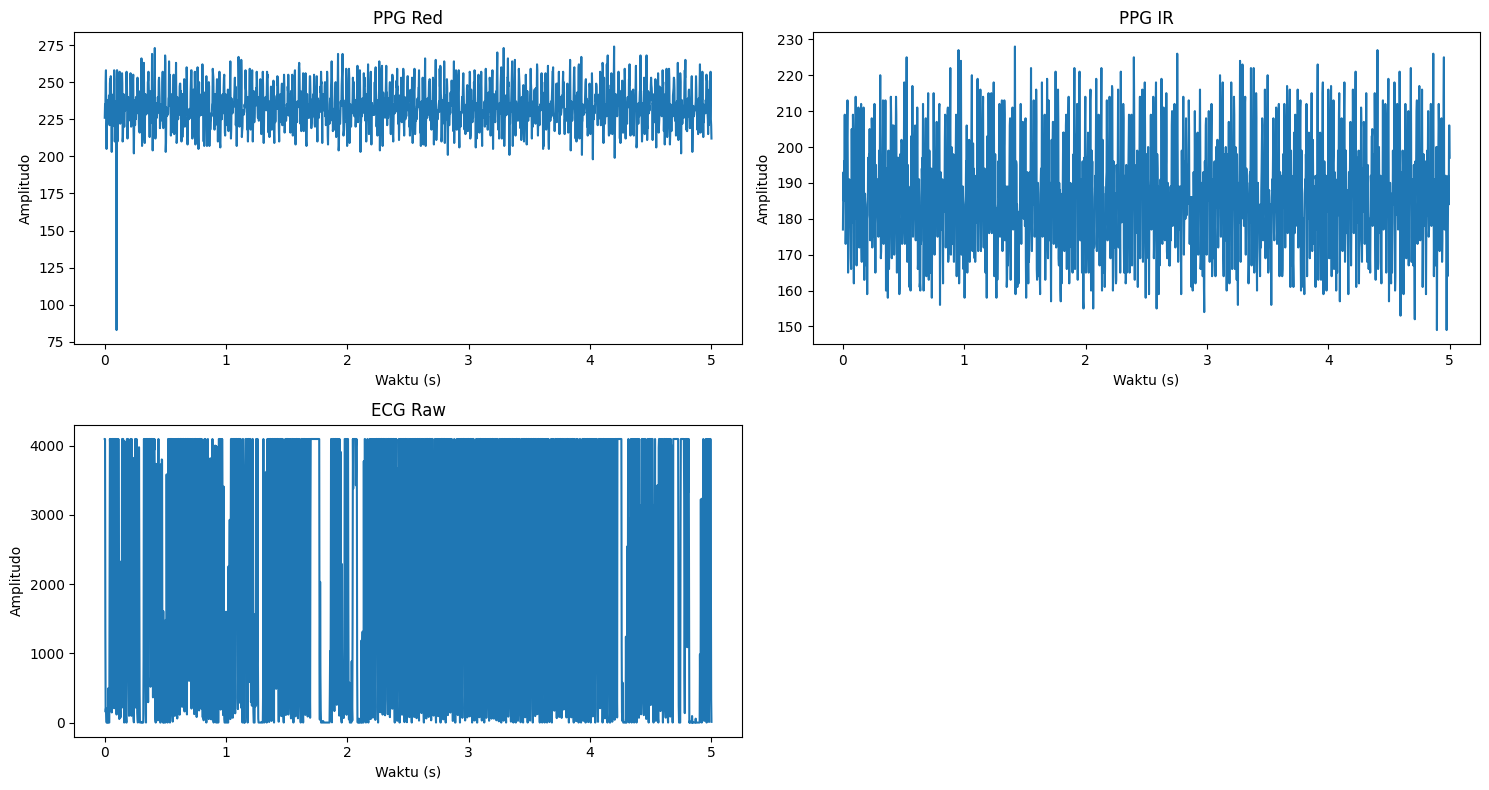

In [5]:
# testing
import pandas as pd
import matplotlib.pyplot as plt

# init
fs = 400
target_fs = 125

df_ppg = pd.read_csv(r'C:\Users\Adyty\Documents\Farid ITS\TriaGo\draft_filter\Data4.csv', sep=',', header=0)
df_ecg = pd.read_csv(r'C:\Users\Adyty\Documents\Farid ITS\TriaGo\draft_filter\Data4.csv', sep=',', header=0)

time_ppg = df_ppg['Time (s)']
ppg_red = df_ppg['PPG_Red']
ppg_ir = df_ppg['PPG_IR']


time_ecg = df_ecg['Time (s)']
ecg = df_ecg['ECG']

fig, ax = plt.subplots(2, 2, figsize=(15, 8))
ax = ax.flatten()
durasi_ppg = time_ppg <= 5
durasi_ecg = time_ecg <= 5

ax[0].plot(time_ppg[durasi_ppg], ppg_red[durasi_ppg])
ax[0].set_title('PPG Red')
ax[0].set_xlabel('Waktu (s)')
ax[0].set_ylabel('Amplitudo')

ax[1].plot(time_ppg[durasi_ppg], ppg_ir[durasi_ppg])
ax[1].set_title('PPG IR')
ax[1].set_xlabel('Waktu (s)')
ax[1].set_ylabel('Amplitudo')

ax[2].plot(time_ecg[durasi_ecg], ecg[durasi_ecg])
ax[2].set_title('ECG Raw')
ax[2].set_xlabel('Waktu (s)')
ax[2].set_ylabel('Amplitudo')

ax[3].remove()

plt.tight_layout()
plt.show()

langkah-langkah PPG

Nilai SpO2: 94.71333549922038
 PI Red: 0.05215227020968582
 PI IR: 0.05991250131181481


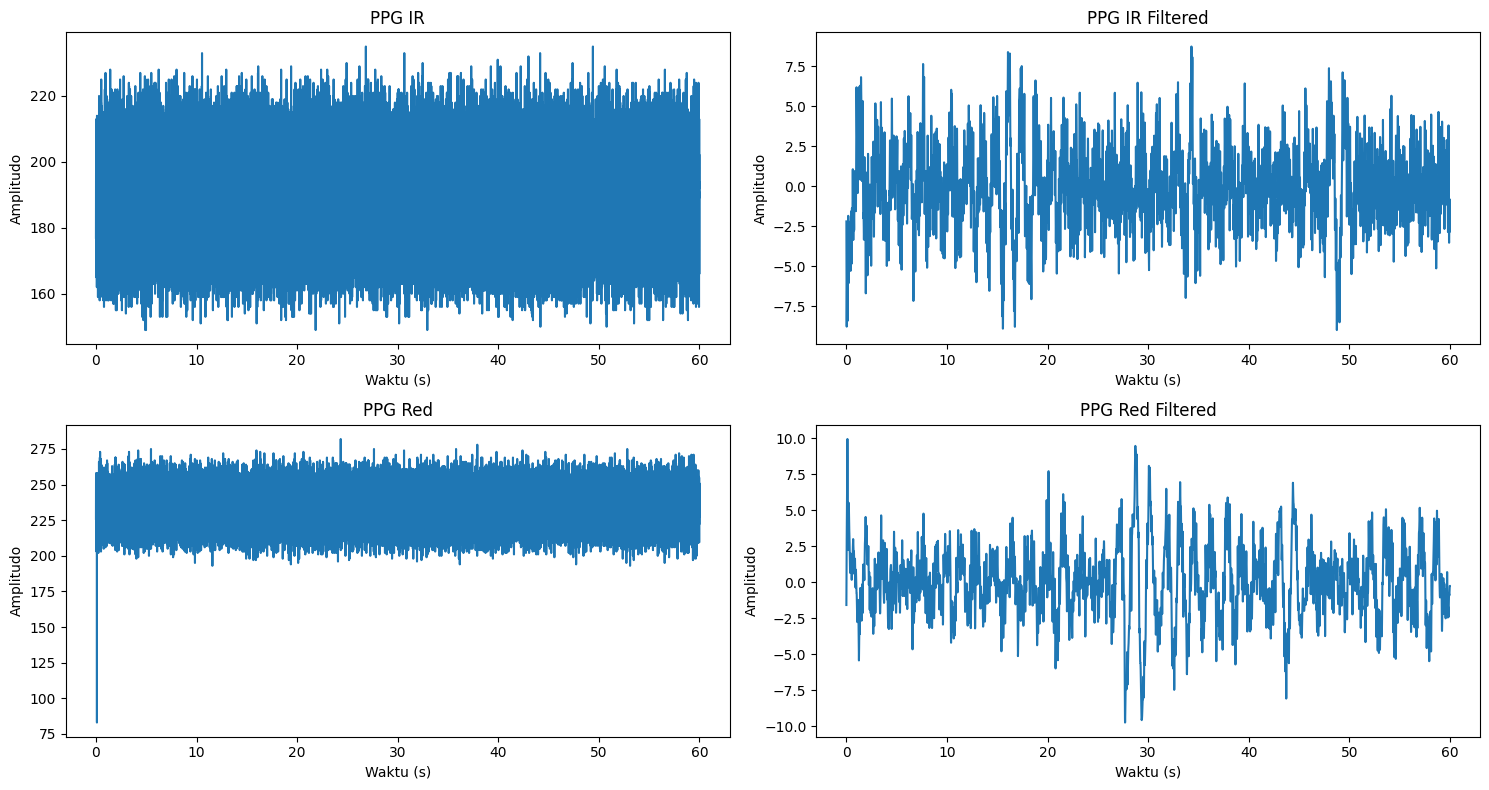

In [6]:
ppg_ir_resample, time_ppg_resample = downsample(ppg_ir, fs, target_fs, time_ppg)
ppg_red_resample, _ = downsample(ppg_red, fs, target_fs, time_ppg)

# invert
ppg_ir_resample = -ppg_ir_resample
ppg_red_resample = -ppg_red_resample

# filter ppg
ppg_ir_clean, baseline_dc_ir = baseline_correction(time_ppg_resample, ppg_ir_resample, fs=125)
ppg_red_clean, baseline_dc_red = baseline_correction(time_ppg_resample, ppg_red_resample)
ppg_ir_clean = bpf(ppg_ir_clean, 0.5,10)
ppg_red_clean = bpf(ppg_red_clean, 0.5,10)

# ekstraksi fitur ppg
ac_ir = ac_p2p(ppg_ir_clean)
ac_red = ac_p2p(ppg_red_clean)

spo2, PI_red, PI_ir = Spo2(ac_ir, baseline_dc_ir, ac_red, baseline_dc_red)
print(f'Nilai SpO2: {spo2}\n PI Red: {PI_red}\n PI IR: {PI_ir}')

fig, ax = plt.subplots(2,2, figsize=(15,8))
ax = ax.flatten()
durasi_resample = time_ppg_resample <= 60
durasi = time_ppg <= 60

ax[0].plot(time_ppg[durasi], ppg_ir[durasi])
ax[0].set_title('PPG IR')
ax[0].set_xlabel('Waktu (s)')
ax[0].set_ylabel('Amplitudo')

ax[1].plot(time_ppg_resample[durasi_resample], ppg_ir_clean[durasi_resample])
ax[1].set_title('PPG IR Filtered')
ax[1].set_xlabel('Waktu (s)')
ax[1].set_ylabel('Amplitudo')

ax[2].plot(time_ppg[durasi], ppg_red[durasi])
ax[2].set_title('PPG Red')
ax[2].set_xlabel('Waktu (s)')
ax[2].set_ylabel('Amplitudo')

ax[3].plot(time_ppg_resample[durasi_resample], ppg_red_clean[durasi_resample])
ax[3].set_title('PPG Red Filtered')
ax[3].set_xlabel('Waktu (s)')
ax[3].set_ylabel('Amplitudo')

plt.tight_layout()
plt.show()


langkah-langkah ECG

Nilai BPM: 113.09992132179384
 Nilai Respiration Rate: 22.25806451612903


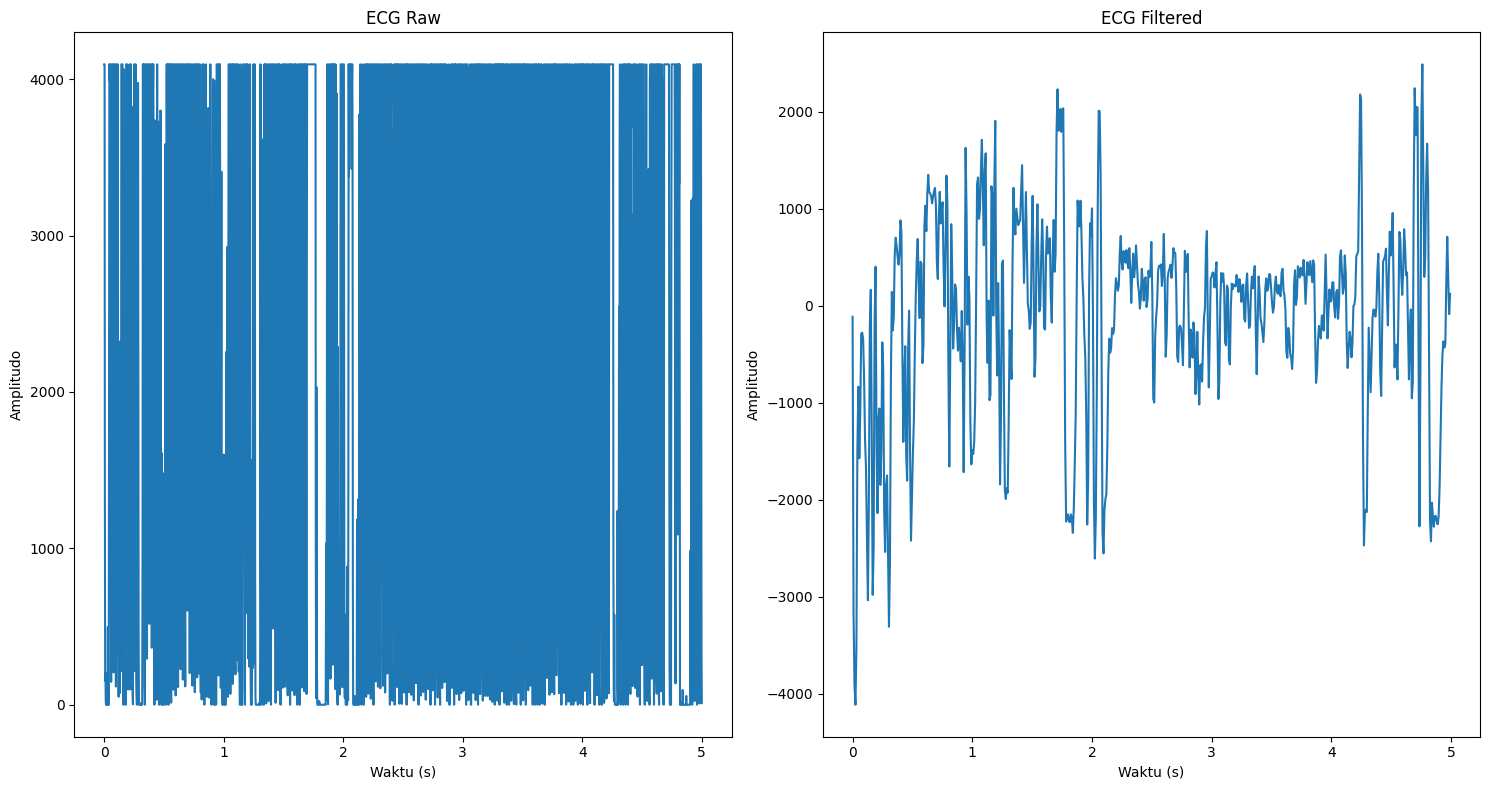

In [7]:
fs_ecg = 400
fs_target = 125

ecg_resample, time_ecg_resample = downsample(ecg, fs_ecg, fs_target, time_ecg)
ecg_clean = bpf(ecg_resample, 0.5, 40)
ecg_clean = notch(ecg_clean)

# ekstraksi fitur ecg
bpm, r_peaks = hr(ecg_clean)
resp_rate = rr(ecg_clean)

print(f'Nilai BPM: {bpm}\n Nilai Respiration Rate: {resp_rate}')

fig, ax = plt.subplots(1,2,figsize=(15,8))
ax = ax.flatten()
durasi_resample = time_ecg_resample <= 5
durasi = time_ecg <= 5

ax[0].plot(time_ecg[durasi], ecg[durasi])
ax[0].set_title('ECG Raw')
ax[0].set_xlabel('Waktu (s)')
ax[0].set_ylabel('Amplitudo')

ax[1].plot(time_ecg_resample[durasi_resample], ecg_clean[durasi_resample])
ax[1].set_title('ECG Filtered')
ax[1].set_xlabel('Waktu (s)')
ax[1].set_ylabel('Amplitudo')

plt.tight_layout()
plt.show()